# TP3

## Exercice 1

### a

In [1]:
import pandas as pd
import lxml
tables = pd.read_html('https://statistique.quebec.ca/fr/document/noms-de-famille-au-quebec/tableau/estimation-de-leffectif-des-1-000-premiers-noms-de-famille-par-ordre-alphabetique-quebec-2005')


### b

On récupère une liste

In [3]:
df = tables[0]
df.to_csv('brut.csv', index=False)

### c

In [4]:
df = pd.read_csv('brut.csv')
print(df.head())
print(df.tail(10))

  Rang2    Nom      n Unnamed: 3 Rang2.1      Nom.1     n.1 Unnamed: 7  \
0   NaN    NaN    NaN        NaN     NaN        NaN     NaN        NaN   
1   570   Adam  2 500        NaN      45    Couture  16 700        NaN   
2   795  Adams  1 700        NaN     711  Couturier   1 900        NaN   
3   931  Ahmed  1 300        NaN     808    Crépeau   1 600        NaN   
4   434  Alain  3 400        NaN     764      Crête   1 800        NaN   

  Rang2.2      Nom.2    n.2 Unnamed: 11 Rang2.3    Nom.3     n.3  
0     NaN        NaN    NaN         NaN     NaN      NaN     NaN  
1     493    Johnson  2 900         NaN     768  Olivier   1 800  
2     590  Jolicoeur  2 400         NaN     735     Otis   1 900  
3     702      Jolin  1 900         NaN      11  Ouellet  33 800  
4     330       Joly  4 600         NaN     300   Ouimet   5 100  
                                                 Rang2  \
249                                                450   
250                                  

In [5]:
df = df.dropna(thresh=5)
df = df.iloc[0:250]

### d


In [6]:
df1 = df.iloc[:, 0:4]
df2 = df.iloc[:, 4:8]
df3 = df.iloc[:, 8:12]
df4 = df.iloc[:, 12:15]

### e

In [7]:
df1 = df1.drop(df1.columns[3], axis=1)
df2 = df2.drop(df2.columns[3], axis=1)
df3 = df3.drop(df3.columns[3], axis=1)

In [8]:
nouveaux_noms = ['rang', 'nom', 'nombre']
df1.columns = nouveaux_noms
df2.columns = nouveaux_noms
df3.columns = nouveaux_noms
df4.columns = nouveaux_noms

### f

In [9]:
df = pd.concat([df1, df2, df3, df4])
df

,rang,nom,nombre
1,570,Adam,2 500
2,795,Adams,1 700
3,931,Ahmed,1 300
4,434,Alain,3 400
5,505,Alarie,2 900
...,...,...,...
246,579,White,2 400
247,544,Williams,2 700
248,554,Wilson,2 600
249,685,Wong,2 000


### g

In [10]:
df.to_csv('noms0.csv', index=True)

## Exercice 2

### a

In [11]:
df = pd.read_csv('noms0.csv', index_col=0)
df
df.sort_values('rang')


,rang,nom,nombre
211,1,Tremblay,81 500
14,1 000,André,1 200
142,10,Gagné,33 900
86,100,Larouche,11 000
117,101,Legault,10 900
...,...,...,...
13,995,Juteau,1 200
127,996,Forcier,1 200
49,997,Pinsonneault,1 200
231,998,Hervieux,1 200


Le problème est qu'en triant par ordre croissant, on a en deuxième place le rang 1000 alors qu'il est censé être  la fin.

### b

In [12]:
df['rang'].astype(int)

ValueError: invalid literal for int() with base 10: '1 000'

On a se message d'erreur qui est renvoyé ValueError: invalid literal for int() with base 10: '1 000'
Cela signifie que le nombre 1000 ne peut pas être transformé dû à son espace

### c

In [13]:
def asint(text):
    texte_str = str(text)
    texte_sans_espace = "".join(texte_str.split())
    return int(texte_sans_espace)

### d

In [14]:
df['rang'] = df['rang'].apply(asint)
df['nombre'] = df['nombre'].apply(asint)
df = df.sort_values('rang')
df

,rang,nom,nombre
211,1,Tremblay,81500
143,2,Gagnon,59800
132,3,Roy,57000
243,4,Côté,52300
120,5,Bouchard,40100
...,...,...,...
127,996,Forcier,1200
49,997,Pinsonneault,1200
231,998,Hervieux,1200
19,999,Daraiche,1200


In [15]:
df = df.reset_index(drop=True)

### e

In [16]:
df35 = df.iloc[:35]

In [17]:
print(df[df['nom'] == 'Deforge'])

Empty DataFrame
Columns: [rang, nom, nombre]
Index: []


## Exercice 3

### a

In [19]:
temp=pd.read_csv('temperature-quotidienne-departementale.csv', sep=';')
temp

,Date,Code INSEE département,Département,TMin (°C),TMax (°C),TMoy (°C)
0,2026-08-31,93,Seine-Saint-Denis,17.40,22.60,20.00
1,2026-08-31,30,Gard,15.87,28.23,22.05
2,2026-08-31,35,Ille-et-Vilaine,15.60,23.05,19.32
3,2026-08-31,37,Indre-et-Loire,16.50,24.50,20.50
4,2026-08-31,40,Landes,17.90,26.10,22.00
...,...,...,...,...,...,...
303835,2018-01-01,04,Alpes-de-Haute-Provence,5.50,11.50,8.50
303836,2018-01-01,72,Sarthe,7.70,11.90,9.80
303837,2018-01-01,56,Morbihan,7.70,12.10,9.90
303838,2018-01-01,41,Loir-et-Cher,6.25,9.65,7.95


In [20]:
temp['Date'] = pd.to_datetime(temp['Date'])
type(temp['Date'][0])

pandas._libs.tslibs.timestamps.Timestamp

### b

In [21]:
temp3=temp[temp['Département'].isin(['Gard', 'Hérault', 'Landes'])]
temp3

,Date,Code INSEE département,Département,TMin (°C),TMax (°C),TMoy (°C)
1,2026-08-31,30,Gard,15.87,28.23,22.05
4,2026-08-31,40,Landes,17.90,26.10,22.00
24,2026-08-31,34,Hérault,21.10,32.40,26.75
126,2026-08-30,30,Gard,15.57,29.80,22.68
129,2026-08-30,40,Landes,19.30,28.40,23.85
...,...,...,...,...,...,...
303697,2018-01-02,30,Gard,1.33,10.20,5.77
303740,2018-01-02,40,Landes,9.23,15.23,12.23
303753,2018-01-01,40,Landes,8.50,13.53,11.02
303793,2018-01-01,30,Gard,4.13,8.93,6.53


### c

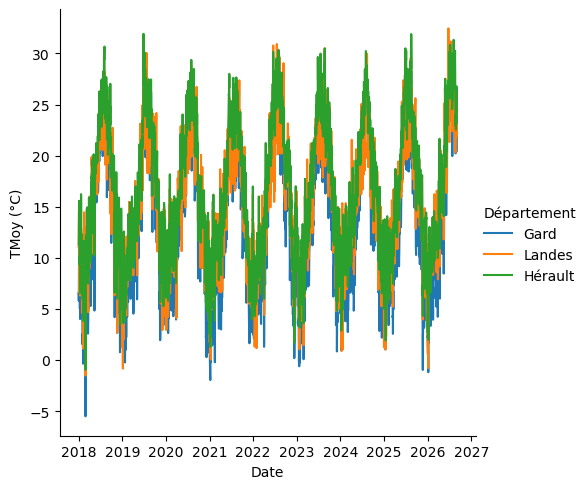

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.relplot(data=temp3, x='Date', y='TMoy (°C)', hue='Département', kind='line')
plt.show()

Les dates sont trop rapprochées et les variations trop fortes pour avoir une bonne lisibilité

### d

In [23]:
def lissage (df, colonne, methode, fenetre):
    temp3_pivot = temp3.pivot(index='Date', columns='Département', values='TMoy (°C)')
    temp3_lisse = temp3_pivot.rolling(fenetre).agg(methode)
    temp3_lisse = temp3_lisse.reset_index()
    temp3_final = temp3_lisse.melt(
        id_vars='Date', 
        var_name='Département', 
        value_name=colonne)
    return temp3_final

In [ ]:
df = lissage(temp3, 'TMoy (°C)', 'mean', '60d')

### e

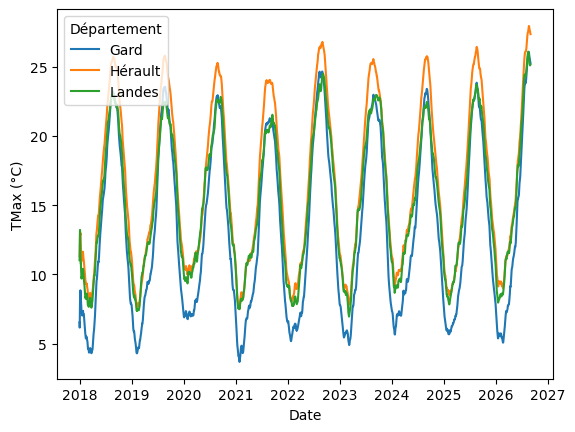

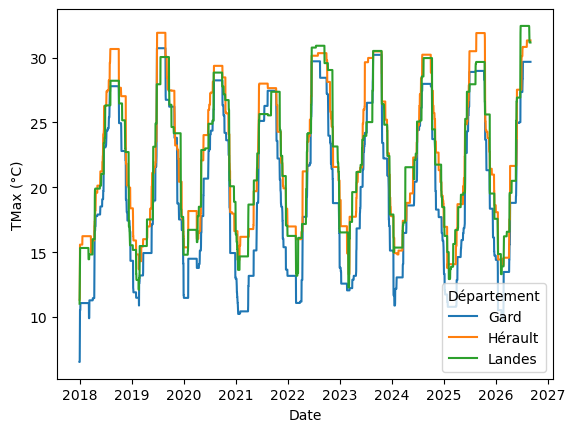

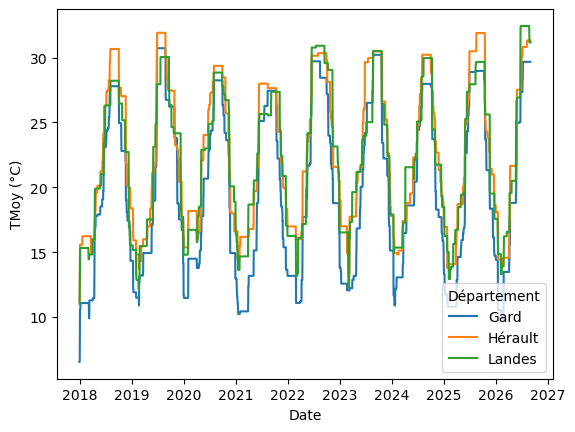

In [24]:
temp_max = lissage(temp, 'TMax (°C)', 'mean', '60D')
sns.lineplot(data=temp_max, x='Date', y='TMax (°C)', hue='Département')
plt.show()

temp_max = lissage(temp, 'TMax (°C)', 'max', '60D')
sns.lineplot(data=temp_max, x='Date', y='TMax (°C)', hue='Département')
plt.show()

temp_max = lissage(temp, 'TMoy (°C)', 'max', '60D')
sns.lineplot(data=temp_max, x='Date', y='TMoy (°C)', hue='Département')
plt.show()

### f

In [25]:
temp['semaine'] = temp['Date'].dt.isocalendar().week
temp['année'] = temp['Date'].dt.isocalendar().year

temp_groupe = temp.groupby(['Département', 'année', 'semaine']).agg(
    tmin=('TMin (°C)', 'min'),
    tmax=('TMax (°C)', 'max')
).reset_index()

### g

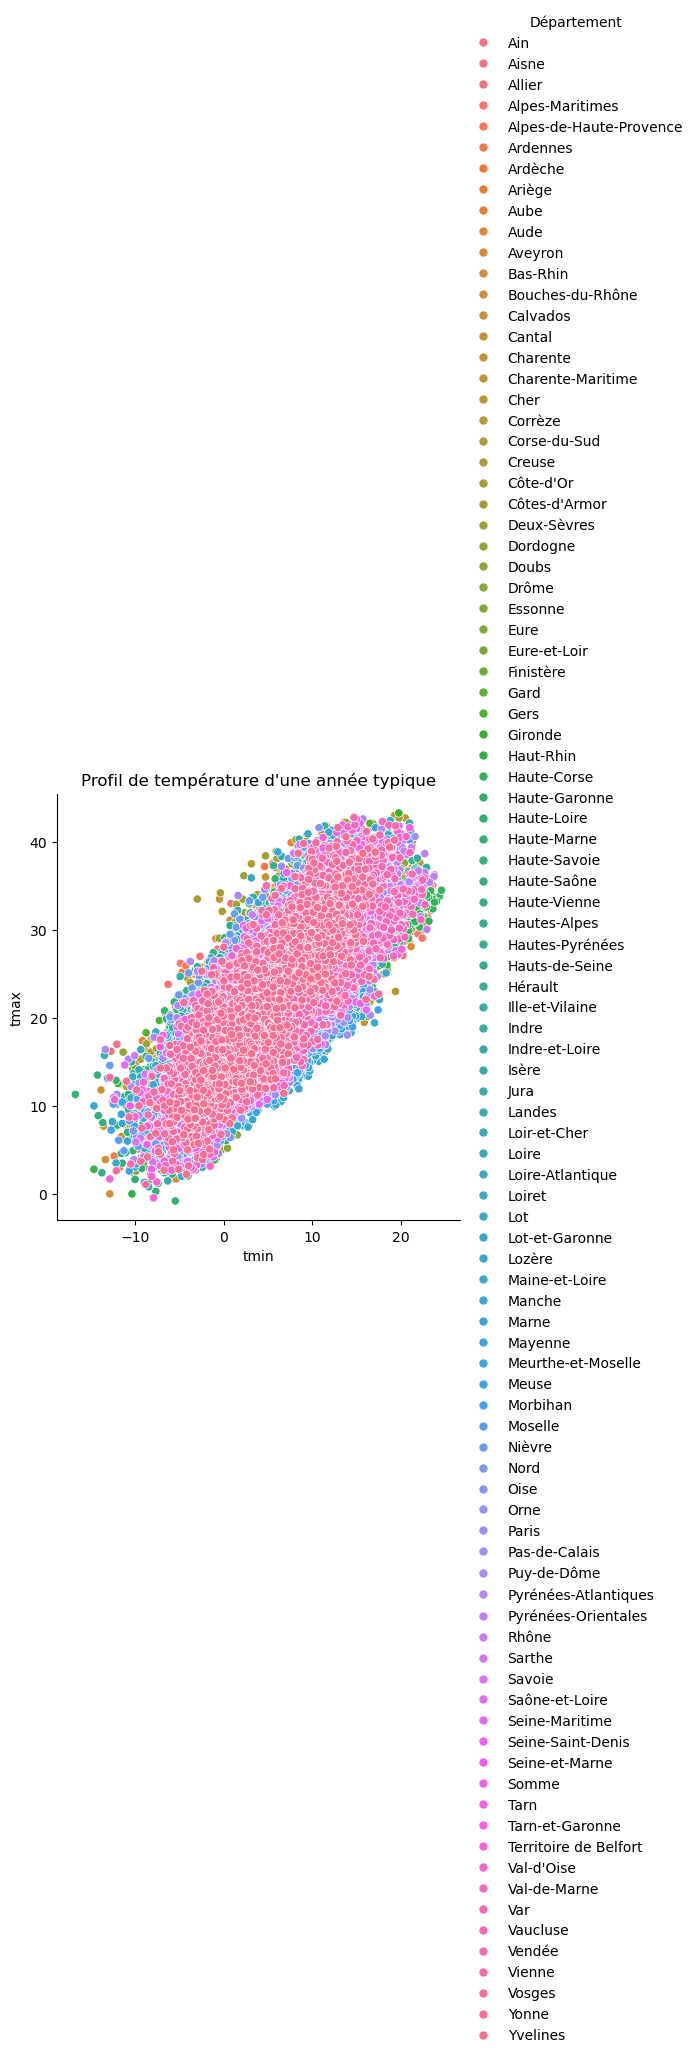

In [26]:
sns.relplot(data=temp_groupe, x='tmin', y='tmax', hue='Département')
plt.title("Profil de température d'une année typique")
plt.show()